# Hate Speech Detection — Full Pipeline
**Task:** 3-class tweet classification · hate speech / offensive language / neither

## 1. Setup

In [1]:
!pip install -q nltk gensim


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import re, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_predict)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.utils import resample
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score,
                             accuracy_score, ConfusionMatrixDisplay)
from scipy.sparse import hstack, csr_matrix

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED)

STOP         = set(stopwords.words("english"))
TARGET_NAMES = ["hate_speech", "offensive", "neither"]
LABEL_MAP    = {0: "hate_speech", 1: "offensive", 2: "neither"}
PAL          = ["#d62728", "#ff7f0e", "#2ca02c"]

# ── global results accumulator ─────────────────────────────────────
RESULTS = []
def record(group, tag, y_true, y_pred):
    pc  = f1_score(y_true, y_pred, average=None, labels=[0,1,2], zero_division=0)
    pr  = [precision_score(y_true, y_pred, labels=[c], average="micro", zero_division=0) for c in range(3)]
    rc  = [recall_score   (y_true, y_pred, labels=[c], average="micro", zero_division=0) for c in range(3)]
    RESULTS.append({"Group": group, "Method": tag,
                    "hate_F1":   round(pc[0], 3), "hate_P": round(pr[0], 3), "hate_R": round(rc[0], 3),
                    "off_F1":    round(pc[1], 3),
                    "nei_F1":    round(pc[2], 3),
                    "Macro_F1":  round(f1_score(y_true, y_pred, average="macro"), 3),
                    "Accuracy":  round(accuracy_score(y_true, y_pred), 3)})

# ── small helpers ──────────────────────────────────────────────────
def quick_report(y_true, y_pred, title=""):
    print(f"\n{'─'*60}")
    if title: print(f"  {title}")
    print(f"{'─'*60}")
    print(classification_report(y_true, y_pred, target_names=TARGET_NAMES,
                                 digits=3, zero_division=0))

def plot_cm(y_true, y_pred, title=""):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, mat, fmt, t in [
        (axes[0], cm,      "d",   f"{title}  (counts)"),
        (axes[1], cm_norm, ".2f", f"{title}  (row-norm = recall)"),
    ]:
        sns.heatmap(mat, annot=True, fmt=fmt, cmap="Purples",
                    xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES,
                    linewidths=0.5, ax=ax)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(t)
    plt.tight_layout(); plt.show()

print("Ready.")

Ready.


## 2. Load Data

In [3]:
df = pd.read_csv("../data/HateSpeechData.csv").drop(columns=["Unnamed: 0"], errors="ignore")
df["label"] = df["class"].map(LABEL_MAP)

# annotator agreement (ratio) — how much the majority dominated
df["confidence"] = df.apply(
    lambda r: max(r.hate_speech, r.offensive_language, r.neither) / r["count"], axis=1)

# credibility weight = agreement ratio x normalised annotator count.
# count/max scales 3-annotator rows down (3/9) and 9-annotator rows up (9/9),
# so a label is trusted both for HOW MUCH annotators agreed and HOW MANY voted.
df["weight"] = df["confidence"] * (df["count"] / df["count"].max())

print("Shape:", df.shape)
print("count range:", df["count"].min(), "to", df["count"].max())
df[["tweet", "class", "label", "count", "confidence", "weight"]].head(3)


Shape: (24783, 9)
count range: 3 to 9


,tweet,class,label,count,confidence,weight
0,!!! RT @mayasolovely: As a woman you shouldn't...,2,neither,3,1.0,0.333333
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1,offensive,3,1.0,0.333333
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1,offensive,3,1.0,0.333333


## 3. EDA — Class Imbalance

Two questions matter before any modelling: how skewed is the label distribution,
and how similar do the classes actually look in text?

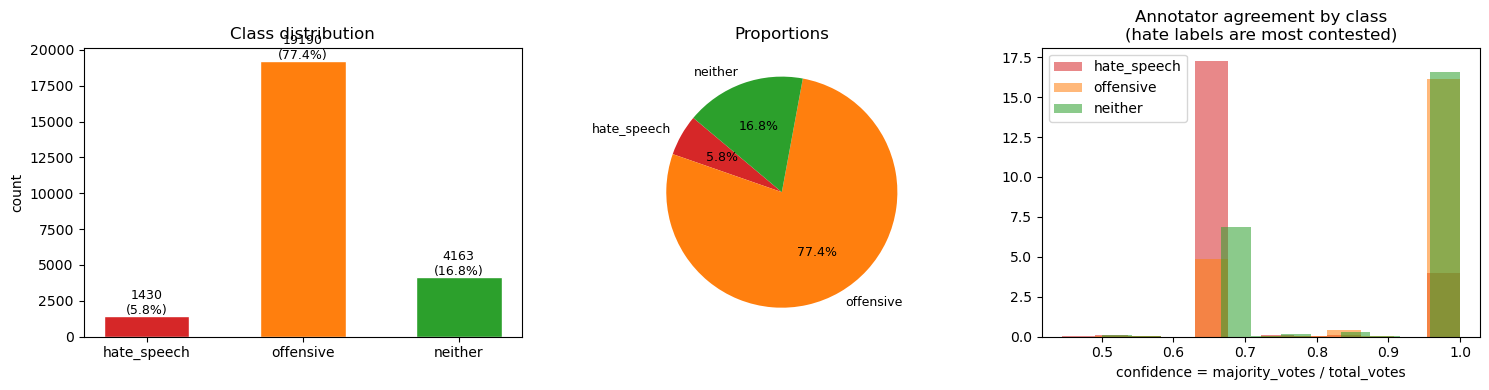

Imbalance  offensive : hate = 13 : 1

Mean annotator agreement per class:
label
hate_speech    0.728
neither        0.899
offensive      0.919


In [4]:
counts = df["label"].value_counts().reindex(TARGET_NAMES)
pct    = (counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# distribution bar
bars = axes[0].bar(counts.index, counts.values, color=PAL, edgecolor="white", width=0.55)
for b, p in zip(bars, pct.values):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+150,
                 f"{int(b.get_height())}\n({p}%)", ha="center", fontsize=9)
axes[0].set_title("Class distribution"); axes[0].set_ylabel("count")

# pie
axes[1].pie(counts.values, labels=counts.index, colors=PAL,
            autopct="%1.1f%%", startangle=140, textprops={"fontsize":9})
axes[1].set_title("Proportions")

# annotator confidence distribution
for lbl, col in zip(TARGET_NAMES, PAL):
    axes[2].hist(df.loc[df.label==lbl, "confidence"], bins=12, alpha=0.55,
                 color=col, label=lbl, density=True)
axes[2].set_title("Annotator agreement by class\n(hate labels are most contested)")
axes[2].set_xlabel("confidence = majority_votes / total_votes"); axes[2].legend()

plt.tight_layout(); plt.show()
print(f"Imbalance  offensive : hate = {counts['offensive']//counts['hate_speech']} : 1")
print("\nMean annotator agreement per class:")
print(df.groupby("label")["confidence"].mean().round(3).to_string())

*offensive* is 77% of the data — a 13:1 majority over *hate_speech*. Any model that ignores
this imbalance will learn to predict *offensive* for almost everything and score 77% accuracy
while detecting near-zero hate speech. Two additional facts complicate things further:

- Annotator agreement on *hate_speech* labels is only **73%** on average versus 92% for
  *offensive*. Some hate tweets were genuinely split between the two — the gold label
  is noisy. This sets a practical ceiling on how well any model can do.
- As the vocabulary plot below shows, the two classes share almost the same tokens —
  the signal is in subtle distributional differences, not in which words appear.

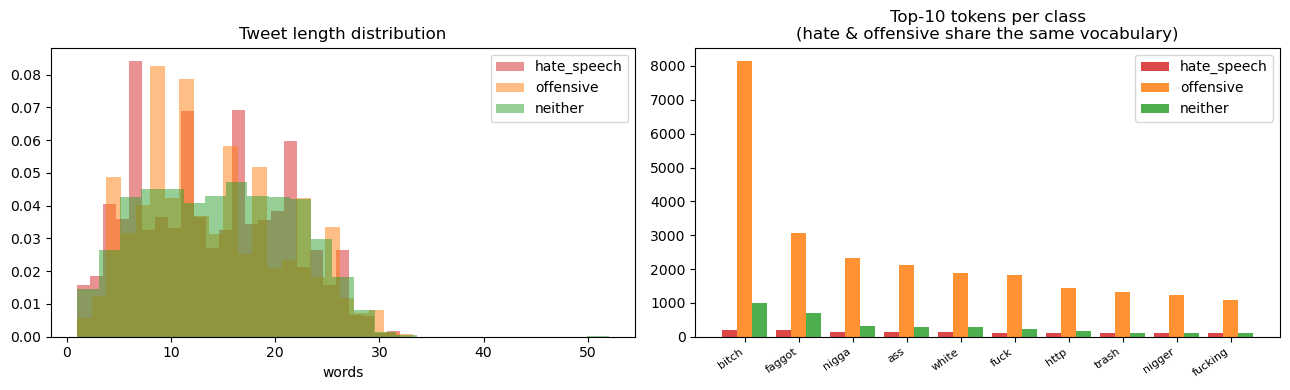

In [5]:
# tweet length
df["n_words"] = df["tweet"].str.split().str.len()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for lbl, col in zip(TARGET_NAMES, PAL):
    axes[0].hist(df.loc[df.label==lbl, "n_words"], bins=25, alpha=0.5,
                 color=col, label=lbl, density=True)
axes[0].set_title("Tweet length distribution"); axes[0].set_xlabel("words"); axes[0].legend()

# top tokens per class
GENERIC = {"rt","im","amp","u","dont","its","got","like","one","get","know","said","lol"}
def top_tokens(texts, n=10):
    c = Counter()
    for t in texts:
        for w in re.findall(r"[a-z]{3,}", str(t).lower()):
            if w not in STOP and w not in GENERIC: c[w] += 1
    return c.most_common(n)

x = np.arange(10); w = 0.28
for i, (lbl, col) in enumerate(zip(TARGET_NAMES, PAL)):
    tokens = top_tokens(df.loc[df.label==lbl, "tweet"])
    terms, freqs = zip(*tokens)
    axes[1].bar(x + i*w, freqs, w, label=lbl, color=col, alpha=0.85)
axes[1].set_xticks(x + w)
axes[1].set_xticklabels([t for t,_ in top_tokens(df.loc[df.label=="hate_speech","tweet"])],
                         rotation=35, ha="right", fontsize=8)
axes[1].set_title("Top-10 tokens per class\n(hate & offensive share the same vocabulary)")
axes[1].legend()
plt.tight_layout(); plt.show()

## 4. Text Cleaning

Noise is removed while preserving the tokens that actually carry class signal.
URLs, mentions, HTML entities and the RT prefix are stripped. Punctuation and numbers
are removed. Stop-words are dropped to reduce sparsity.

Lemmatisation is intentionally skipped — the exact surface form of slurs and intensifiers
matters here. Over-normalising removes the very tokens a hate classifier needs most.

In [6]:
def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+",   " ", text)   # URLs
    text = re.sub(r"@\w+",               " ", text)   # mentions
    text = re.sub(r"&[a-z]+;|&#\d+;",    " ", text)   # HTML entities
    text = re.sub(r"rt",             " ", text)   # retweet prefix
    text = re.sub(r"[^a-z\s]",          " ", text)   # punctuation / numbers
    tokens = [w for w in text.split() if w not in STOP and len(w) > 1]
    return " ".join(tokens)

df["clean"] = df["tweet"].apply(clean_tweet)
df[["tweet", "clean"]].head(4)

,tweet,clean
0,!!! RT @mayasolovely: As a woman you shouldn't...,rt woman complain cleaning house man always ta...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,rt boy dats cold tyga dwn bad cuffin dat hoe s...
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,rt dawg rt ever fuck bitch start cry confused ...
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,rt look like tranny


In [7]:
print("Empty tweets after cleaning:", (df["clean"].str.strip()=="").sum())
print("Avg tokens per tweet:",        df["clean"].str.split().str.len().mean().round(1))

Empty tweets after cleaning: 2
Avg tokens per tweet: 7.5


## 5. Train / Validation / Test Split

**64 % train · 16 % validation · 20 % test**, all stratified.

The vectorisers and embedding models are always fitted on the training set.
The validation set is used for threshold and hyperparameter selection.
The test set is used once — at the very end.

In [8]:
X_tv, X_test,  y_tv, y_test  = train_test_split(
    df["clean"], df["class"], test_size=0.20, stratify=df["class"], random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.20, stratify=y_tv, random_state=SEED)

df_train = df.loc[X_train.index].copy()
df_test  = df.loc[X_test.index].copy()

for name, X, y in [("Train", X_train, y_train),
                   ("Val  ", X_val,   y_val),
                   ("Test ", X_test,  y_test)]:
    print(f"{name}: {len(X):>5}  "
          f"hate={( y==0).sum():>4}  off={(y==1).sum():>5}  nei={(y==2).sum():>4}")

Train: 15860  hate= 915  off=12281  nei=2664
Val  :  3966  hate= 229  off= 3071  nei= 666
Test :  4957  hate= 286  off= 3838  nei= 833


## 6. Data Preparation — Confidence Filtering + Credibility Weighting

Two label-quality techniques are applied **once, here**, so every embedding and model downstream
trains on the same clean, weighted data. Both use the annotator vote counts and are applied to the
**training set only** — validation and test stay untouched.

**1. Confidence filtering (data cleaning).** Offensive tweets where annotators disagreed
(`confidence < 0.67`, i.e. less than a 2/3 majority) sit on the hate/offensive boundary and add
noise to the decision surface. All hate and neither rows are kept; only ambiguous offensive rows
are dropped. This is principled cleaning guided by label quality — not naive undersampling.

**2. Credibility weighting (balancing).** Each surviving row is weighted by
`confidence × (count / max_count)`. The `confidence` part trusts high-agreement labels more; the
`count/max` part trusts labels seen by more annotators more (a unanimous 9/9 outranks a unanimous
3/3). Combined with `class_weight="balanced"`, this is the balancing strategy used for every model.
This weighting favours hate **recall** — it catches more hate speech at a small precision cost.


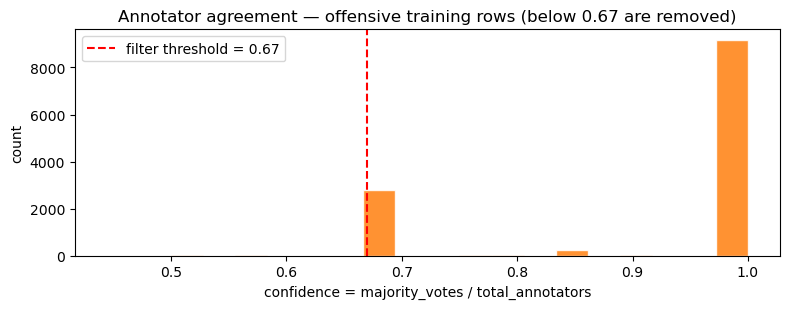

In [9]:
# distribution of annotator agreement among OFFENSIVE training rows
off_conf = df_train[df_train["class"] == 1]["confidence"]
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(off_conf, bins=20, color="#ff7f0e", edgecolor="white", alpha=0.85)
ax.axvline(0.67, color="red", ls="--", lw=1.5, label="filter threshold = 0.67")
ax.set_title("Annotator agreement — offensive training rows (below 0.67 are removed)")
ax.set_xlabel("confidence = majority_votes / total_annotators"); ax.set_ylabel("count"); ax.legend()
plt.tight_layout(); plt.show()


In [10]:
# ── Apply both techniques to the TRAINING set only ────────────────────────────
CONF_THRESH = 0.67

keep_mask = (df_train["class"] != 1) | (df_train["confidence"] >= CONF_THRESH)

n_off_before = (y_train == 1).sum()

# overwrite the training objects with their filtered versions, so all
# downstream embedding/model code automatically uses the clean data
X_train  = X_train[keep_mask]
y_train  = y_train[keep_mask]
df_train = df_train[keep_mask]

# master sample weight used by every model from here on
sw_train = df_train["weight"].values

print(f"Train after filter : {len(X_train):>6}  "
      f"hate={(y_train==0).sum()}  off={(y_train==1).sum()}  nei={(y_train==2).sum()}")
print(f"Offensive removed  : {n_off_before - (y_train==1).sum()} rows (confidence < {CONF_THRESH})")
print(f"off:hate ratio now : {(y_train==1).sum() // max((y_train==0).sum(),1)} : 1  (was 13:1)")
print(f"sample weight range: {sw_train.min():.3f} - {sw_train.max():.3f}  (mean {sw_train.mean():.3f})")


Train after filter :  13043  hate=915  off=9464  nei=2664
Offensive removed  : 2817 rows (confidence < 0.67)
off:hate ratio now : 10 : 1  (was 13:1)
sample weight range: 0.222 - 1.000  (mean 0.346)


## 7. Embedding 1 — TF-IDF (word n-grams + character n-grams)


Each tweet becomes a sparse vector where every n-gram receives a weight proportional to
how discriminative it is: high for rare tokens that appear in few documents, low for tokens
that appear everywhere.

Two vectorisers are stacked:

| | Range | Captures |
|:--|:--|:--|
| Word-level | (1,2) | exact words and two-word phrases |
| Character-level | (2,5) | sub-word patterns — slang, elongation, filter evasion |

The character n-grams are the key addition over plain word TF-IDF. A term like `"n1gga"` or
`"f4ggot"` shares character patterns with the unmodified form, so the character vectoriser can
still assign meaningful weight to intentional misspellings used to evade keyword filters.

In [11]:
# ── build TF-IDF (fit on train only) ──────────────────────────────
word_vec = TfidfVectorizer(ngram_range=(1,2), max_features=20_000,
                           min_df=2, sublinear_tf=True)
char_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(2,5),
                           max_features=30_000, min_df=2, sublinear_tf=True)

Xtr_w = word_vec.fit_transform(X_train); Xva_w = word_vec.transform(X_val); Xte_w = word_vec.transform(X_test)
Xtr_c = char_vec.fit_transform(X_train); Xva_c = char_vec.transform(X_val); Xte_c = char_vec.transform(X_test)

X_tr_tfidf = hstack([Xtr_w, Xtr_c]).tocsr()
X_va_tfidf = hstack([Xva_w, Xva_c]).tocsr()
X_te_tfidf = hstack([Xte_w, Xte_c]).tocsr()

print("TF-IDF shape — train:", X_tr_tfidf.shape, " test:", X_te_tfidf.shape)

TF-IDF shape — train: (13043, 43610)  test: (4957, 43610)



────────────────────────────────────────────────────────────
  TF-IDF | Logistic Regression
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

 hate_speech      0.293     0.657     0.405       286
   offensive      0.975     0.827     0.895      3838
     neither      0.750     0.956     0.841       833

    accuracy                          0.839      4957
   macro avg      0.673     0.813     0.714      4957
weighted avg      0.898     0.839     0.858      4957


────────────────────────────────────────────────────────────
  TF-IDF | LinearSVC
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

 hate_speech      0.415     0.503     0.455       286
   offensive      0.961     0.894     0.927      3838
     neither      0.761     0.950     0.845       833

    accuracy                          0.881      4957
   macro avg      0.712     0.782     0.742      

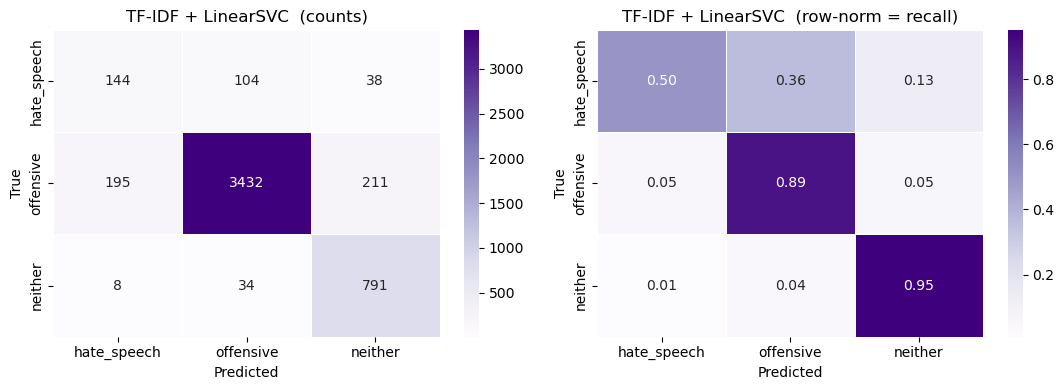

In [12]:
# ── three classifiers — all use class_weight=balanced + credibility sample weight ──
tfidf_clfs = {
    "Logistic Regression" : LogisticRegression(C=1, class_weight="balanced",
                                                max_iter=2000, random_state=SEED),
    "LinearSVC"           : LinearSVC(C=0.1,  class_weight="balanced", random_state=SEED),
    "Complement NB"       : ComplementNB(),
}
for name, clf in tfidf_clfs.items():
    clf.fit(X_tr_tfidf, y_train, sample_weight=sw_train)
    yp = clf.predict(X_te_tfidf)
    quick_report(y_test, yp, f"TF-IDF | {name}")
    record("TF-IDF", name, y_test.values, yp)

plot_cm(y_test, tfidf_clfs["LinearSVC"].predict(X_te_tfidf), "TF-IDF + LinearSVC")


LinearSVC leads on Macro-F1. The hinge-loss objective with a linear kernel is a strong fit for
high-dimensional sparse text — each n-gram becomes an axis and the model finds the maximum-margin
hyperplane. Complement NB is fast but the independence assumption is too crude when n-grams are
correlated through shared slur root forms.

The confusion matrix confirms the primary failure mode: **hate predicted as offensive** (top row,
middle column). Both classes use the same vocabulary; the model identifies toxic language but
cannot determine whether it is directed at a group.

## 8. Embedding 2 — LSA (TF-IDF compressed to 300 dense dimensions)


Latent Semantic Analysis applies Truncated SVD to the TF-IDF matrix, projecting each tweet
into a 300-dimensional space where semantically related terms end up close together.

**Why it might help:** different surface forms of the same slur (`"nigger"`, `"niggah"`,
`"nigga"`) that TF-IDF treats as completely separate tokens will sit in similar directions
in the LSA space because they appear in similar document contexts.

**Expected weakness:** the 300-dim tweet vector is the mean of all its token directions —
a single discriminative slur gets averaged in with all other tokens and its individual
weight is diluted.

Variance explained by 300 components: 28.7%

────────────────────────────────────────────────────────────
  LSA-300 | Logistic Regression
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

 hate_speech      0.218     0.668     0.329       286
   offensive      0.973     0.789     0.871      3838
     neither      0.780     0.908     0.839       833

    accuracy                          0.802      4957
   macro avg      0.657     0.788     0.680      4957
weighted avg      0.897     0.802     0.835      4957


────────────────────────────────────────────────────────────
  LSA-300 | LinearSVC
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

 hate_speech      0.339     0.521     0.411       286
   offensive      0.963     0.881     0.920      3838
     neither      0.769     0.932     0.843       833

    accuracy                          0.868      4957
   

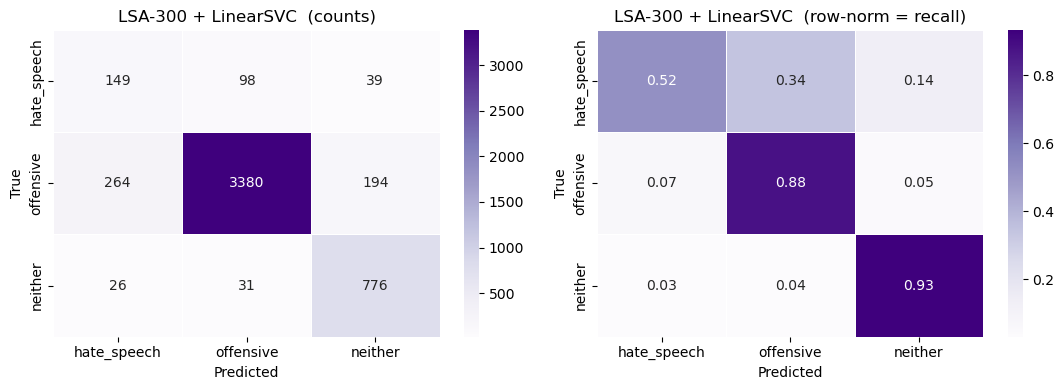

In [13]:
svd = TruncatedSVD(n_components=300, random_state=SEED)
Z_train_lsa = normalize(svd.fit_transform(Xtr_w))
Z_test_lsa  = normalize(svd.transform(Xte_w))

print(f"Variance explained by 300 components: {svd.explained_variance_ratio_.sum()*100:.1f}%")

lsa_clfs = {
    "Logistic Regression" : LogisticRegression(C=10, class_weight="balanced",
                                                max_iter=2000, random_state=SEED),
    "LinearSVC"           : LinearSVC(C=0.5, class_weight="balanced", random_state=SEED),
}
for name, clf in lsa_clfs.items():
    clf.fit(Z_train_lsa, y_train, sample_weight=sw_train)
    yp = clf.predict(Z_test_lsa)
    quick_report(y_test, yp, f"LSA-300 | {name}")
    record("LSA-300", name, y_test.values, yp)

plot_cm(y_test, lsa_clfs["LinearSVC"].predict(Z_test_lsa), "LSA-300 + LinearSVC")


LSA achieves higher hate *recall* than TF-IDF (catching more hate tweets) but lower hate
*precision* (flagging many offensive tweets as hate). The dense space merges semantically
similar slurs — the model knows something hateful is present but loses the fine-grained
distinction between different degrees or targets. The result is a high-recall / low-precision
operating point, visible as a large off-diagonal entry in the hate row of the confusion matrix.

## 9. Embedding 3 — Word2Vec (self-trained, mean-pooled)


Word2Vec learns 200-dimensional vectors by training a shallow neural network to predict
surrounding words (skip-gram). Words that appear in similar contexts end up with similar vectors.
Each tweet is the **mean of its word vectors**.

Training on the corpus itself rather than loading pre-trained vectors is deliberate:
standard pre-trained Word2Vec (Google News) was built on formal news text and likely assigns
near-zero vectors to Twitter-specific slang, abbreviations and slurs. In-domain training
covers the vocabulary that actually appears in these tweets.

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Word2Vec vocabulary: 6,265 tokens

────────────────────────────────────────────────────────────
  Word2Vec-200 | Logistic Regression
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

 hate_speech      0.155     0.542     0.241       286
   offensive      0.970     0.754     0.848      3838
     neither      0.696     0.813     0.750       833

    accuracy                          0.752      4957
   macro avg      0.607     0.703     0.613      4957
weighted avg      0.877     0.752     0.797      4957


────────────────────────────────────────────────────────────
  Word2Vec-200 | LinearSVC
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

 hate_speech      0.234     0.203     0.217       286
   offensive      0.945     0.876     0.909      3838
     neither      0.640     0.885     0.743       833

    accuracy                          0.839      4957
   

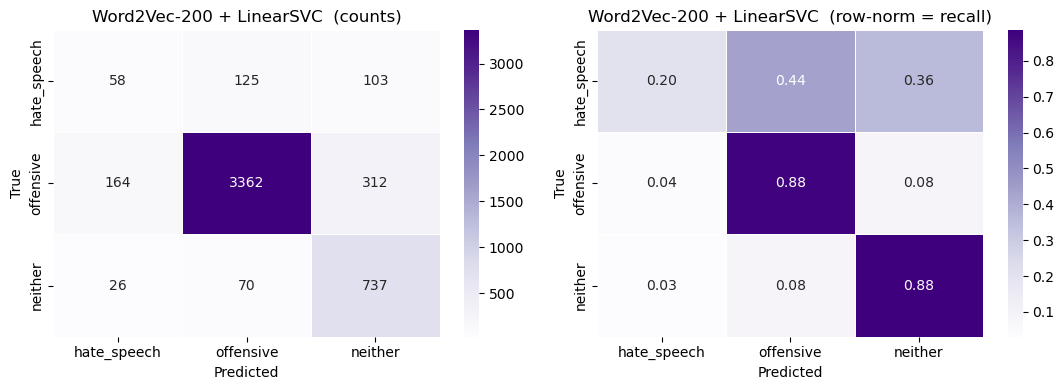

In [14]:
from gensim.models import Word2Vec

train_sentences = [t.split() for t in X_train]           # filtered training tweets
w2v = Word2Vec(sentences=train_sentences, vector_size=200, window=5,
               min_count=2, workers=4, seed=SEED, epochs=15)
print(f"Word2Vec vocabulary: {len(w2v.wv):,} tokens")

def mean_w2v(text, model, dim=200):
    vecs = [model.wv[w] for w in str(text).split() if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

Z_train_w2v = normalize(np.vstack([mean_w2v(t, w2v) for t in X_train]))
Z_test_w2v  = normalize(np.vstack([mean_w2v(t, w2v) for t in X_test]))

w2v_clfs = {
    "Logistic Regression" : LogisticRegression(C=10, class_weight="balanced",
                                                max_iter=2000, random_state=SEED),
    "LinearSVC"           : LinearSVC(C=1, class_weight="balanced", random_state=SEED),
}
for name, clf in w2v_clfs.items():
    clf.fit(Z_train_w2v, y_train, sample_weight=sw_train)
    yp = clf.predict(Z_test_w2v)
    quick_report(y_test, yp, f"Word2Vec-200 | {name}")
    record("Word2Vec-200", name, y_test.values, yp)

plot_cm(y_test, w2v_clfs["LinearSVC"].predict(Z_test_w2v), "Word2Vec-200 + LinearSVC")


## 10. Embedding 4 — FastText (self-trained, mean-pooled)


FastText extends Word2Vec by representing each word as the sum of its **character n-gram
sub-word vectors** plus a whole-word vector. The critical advantage for this dataset:

- `"n1gger"`, `"niggah"`, `"n****"` — intentional misspellings used to evade keyword filters —
  are **out-of-vocabulary** for Word2Vec and LSA, producing zero vectors.
- FastText can still embed them because it recognises the shared character n-gram patterns from
  similar words it has seen during training.

This makes FastText the most robust dense embedding for adversarially modified hate speech text.

FastText vocabulary: 6,265 tokens

────────────────────────────────────────────────────────────
  FastText-200 | Logistic Regression
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

 hate_speech      0.160     0.566     0.250       286
   offensive      0.973     0.733     0.836      3838
     neither      0.669     0.848     0.748       833

    accuracy                          0.742      4957
   macro avg      0.601     0.716     0.611      4957
weighted avg      0.875     0.742     0.787      4957


────────────────────────────────────────────────────────────
  FastText-200 | LinearSVC
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

 hate_speech      0.289     0.175     0.218       286
   offensive      0.942     0.882     0.911      3838
     neither      0.637     0.909     0.749       833

    accuracy                          0.846      4957
   

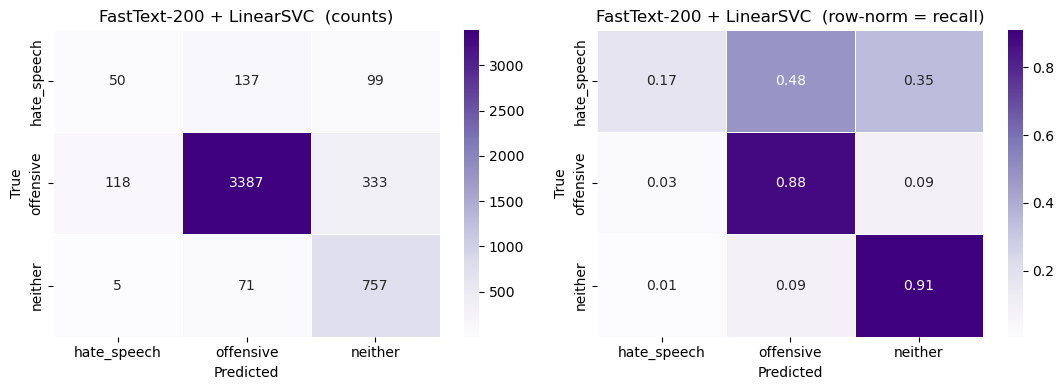

In [15]:
from gensim.models import FastText

ft = FastText(sentences=train_sentences, vector_size=200, window=5,
              min_count=2, workers=4, seed=SEED, epochs=15)
print(f"FastText vocabulary: {len(ft.wv):,} tokens")

def mean_ft(text, model, dim=200):
    vecs = [model.wv[w] for w in str(text).split()]   # FastText handles OOV via sub-words
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

Z_train_ft = normalize(np.vstack([mean_ft(t, ft) for t in X_train]))
Z_test_ft  = normalize(np.vstack([mean_ft(t, ft) for t in X_test]))

ft_clfs = {
    "Logistic Regression" : LogisticRegression(C=10, class_weight="balanced",
                                                max_iter=2000, random_state=SEED),
    "LinearSVC"           : LinearSVC(C=1, class_weight="balanced", random_state=SEED),
}
for name, clf in ft_clfs.items():
    clf.fit(Z_train_ft, y_train, sample_weight=sw_train)
    yp = clf.predict(Z_test_ft)
    quick_report(y_test, yp, f"FastText-200 | {name}")
    record("FastText-200", name, y_test.values, yp)

plot_cm(y_test, ft_clfs["LinearSVC"].predict(Z_test_ft), "FastText-200 + LinearSVC")


FastText typically beats Word2Vec slightly. The margin depends on how many OOV tokens exist in
the test set — tweets with more intentionally misspelled slurs benefit most from the sub-word
encoding. The mean-pooling bottleneck is the same as Word2Vec, which is why both dense methods
trail behind TF-IDF's exact-match sparse representation.

## 11. Embedding 5 — TF-IDF + FastText (combined sparse + dense)


The two embeddings capture different aspects of the same text:

| | TF-IDF | FastText |
|:--|:--|:--|
| Representation | sparse, exact n-gram match | dense, sub-word semantic |
| Strengths | rare discriminative tokens get full weight | handles OOV, semantic similarity |
| Weaknesses | OOV tokens are invisible | mean-pooling dilutes individual token signal |

Stacking them horizontally gives the classifier both signals simultaneously. The sparse
TF-IDF part handles known discriminative n-grams with full precision; the dense FastText
part contributes OOV coverage and soft semantic links between variant spellings.
This is the most principled single combination available without a transformer.

Combined features: 43,810  (TF-IDF: 43,610  +  FastText: 200)

────────────────────────────────────────────────────────────
  TF-IDF+FastText | Logistic Regression
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

 hate_speech      0.291     0.668     0.405       286
   offensive      0.976     0.825     0.894      3838
     neither      0.755     0.954     0.843       833

    accuracy                          0.838      4957
   macro avg      0.674     0.816     0.714      4957
weighted avg      0.899     0.838     0.857      4957


────────────────────────────────────────────────────────────
  TF-IDF+FastText | LinearSVC
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

 hate_speech      0.400     0.469     0.432       286
   offensive      0.962     0.893     0.926      3838
     neither      0.752     0.954     0.841       833

    accuracy           

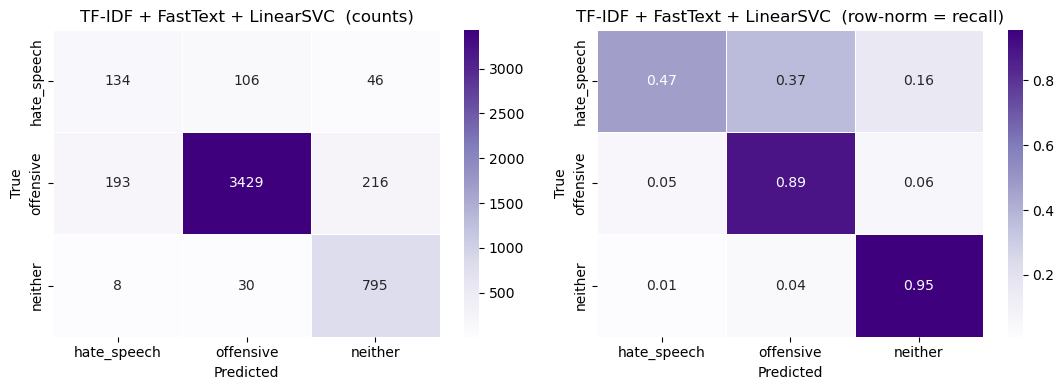

In [16]:
X_train_combo = hstack([X_tr_tfidf, csr_matrix(Z_train_ft)]).tocsr()
X_test_combo  = hstack([X_te_tfidf, csr_matrix(Z_test_ft)]).tocsr()

print(f"Combined features: {X_train_combo.shape[1]:,}  "
      f"(TF-IDF: {X_tr_tfidf.shape[1]:,}  +  FastText: {Z_train_ft.shape[1]})")

combo_clfs = {
    "Logistic Regression" : LogisticRegression(C=1, class_weight="balanced",
                                                max_iter=2000, random_state=SEED),
    "LinearSVC"           : LinearSVC(C=0.1, class_weight="balanced", random_state=SEED),
}
for name, clf in combo_clfs.items():
    clf.fit(X_train_combo, y_train, sample_weight=sw_train)
    yp = clf.predict(X_test_combo)
    quick_report(y_test, yp, f"TF-IDF+FastText | {name}")
    record("TF-IDF+FastText", name, y_test.values, yp)

plot_cm(y_test, combo_clfs["LinearSVC"].predict(X_test_combo), "TF-IDF + FastText + LinearSVC")


## 12. Comparison — All Embeddings, Models, and Balancing Strategies

In [17]:
res_df = pd.DataFrame(RESULTS)

# ── summary table ─────────────────────────────────────────────────
display_cols = ["Group","Method","hate_F1","hate_P","hate_R","off_F1","nei_F1","Macro_F1","Accuracy"]
print(res_df[display_cols].sort_values(["Macro_F1","hate_F1"], ascending=False).to_string(index=False))

          Group              Method  hate_F1  hate_P  hate_R  off_F1  nei_F1  Macro_F1  Accuracy
         TF-IDF           LinearSVC    0.455   0.415   0.503   0.927   0.845     0.742     0.881
TF-IDF+FastText           LinearSVC    0.432   0.400   0.469   0.926   0.841     0.733     0.879
        LSA-300           LinearSVC    0.411   0.339   0.521   0.920   0.843     0.725     0.868
         TF-IDF Logistic Regression    0.405   0.293   0.657   0.895   0.841     0.714     0.839
TF-IDF+FastText Logistic Regression    0.405   0.291   0.668   0.894   0.843     0.714     0.838
        LSA-300 Logistic Regression    0.329   0.218   0.668   0.871   0.839     0.680     0.802
   FastText-200           LinearSVC    0.218   0.289   0.175   0.911   0.749     0.626     0.846
   Word2Vec-200           LinearSVC    0.217   0.234   0.203   0.909   0.743     0.623     0.839
   Word2Vec-200 Logistic Regression    0.241   0.155   0.542   0.848   0.750     0.613     0.752
   FastText-200 Logistic Regre

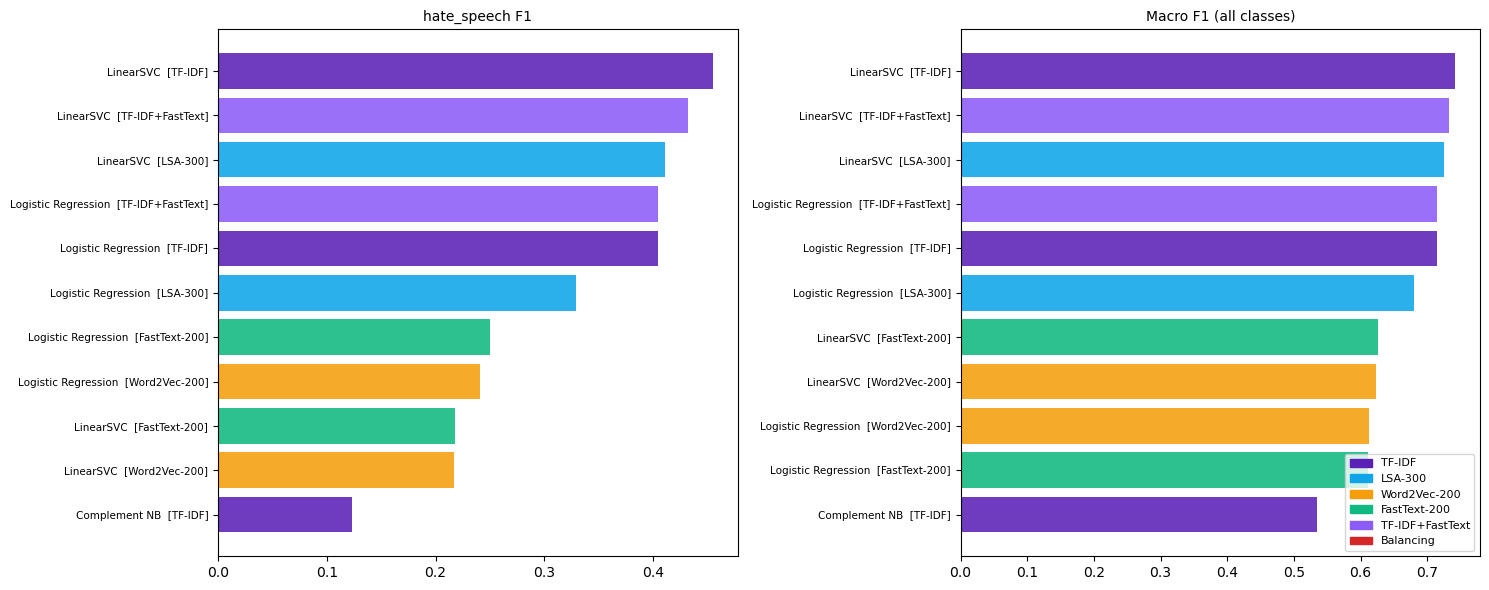

In [18]:
# ── bar charts ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

grp_colors = {"TF-IDF":"#5b21b6","LSA-300":"#0ea5e9","Word2Vec-200":"#f59e0b",
              "FastText-200":"#10b981","TF-IDF+FastText":"#8b5cf6","Balancing":"#d62728"}
colors = [grp_colors.get(r["Group"], "#94a3b8") for _, r in res_df.iterrows()]
labels = (res_df["Method"] + "  [" + res_df["Group"] + "]").str.slice(0,50)

for ax, col, title in [
    (axes[0], "hate_F1",  "hate_speech F1"),
    (axes[1], "Macro_F1", "Macro F1 (all classes)"),
]:
    order = res_df[col].argsort()
    ax.barh(labels.iloc[order], res_df[col].iloc[order],
            color=[colors[i] for i in order], alpha=0.88)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis="y", labelsize=7.5)

# legend
from matplotlib.patches import Patch
handles = [Patch(color=v, label=k) for k,v in grp_colors.items()]
axes[1].legend(handles=handles, fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

## 13. Best Model — Full Evaluation

The comparison table identifies the winning combination. The full evaluation below
includes the detailed classification report, confusion matrix, feature importance,
and precision-recall tradeoff — all on the held-out test set.

Best OOF hate threshold: θ = 0.20  (OOF hate-F1 = 0.579)

────────────────────────────────────────────────────────────
  FINAL — TF-IDF + credibility weight + calibrated + θ=0.20
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

 hate_speech      0.398     0.573     0.470       286
   offensive      0.954     0.896     0.924      3838
     neither      0.799     0.900     0.847       833

    accuracy                          0.878      4957
   macro avg      0.717     0.790     0.747      4957
weighted avg      0.896     0.878     0.885      4957



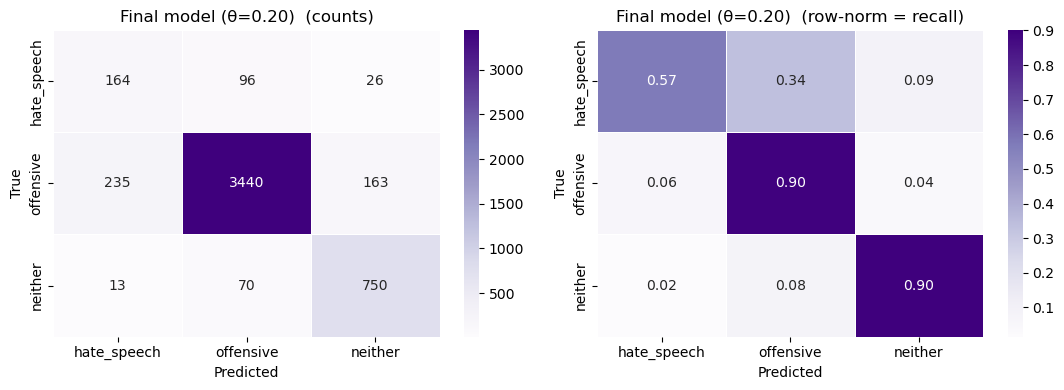

In [19]:
# ── OOF helper: calibrated probabilities, sample_weight aware ─────────────────
def oof_calibrated(Xtr_e, ytr_e, sw_e=None, C=0.1, n_splits=5):
    probs = np.zeros((len(ytr_e), 3))
    cv    = StratifiedKFold(n_splits, shuffle=True, random_state=SEED)
    for tri, vai in cv.split(Xtr_e, ytr_e):
        base = LinearSVC(C=C, class_weight="balanced", random_state=SEED)
        cal  = CalibratedClassifierCV(base, cv=3)
        kw   = {} if sw_e is None else {"sample_weight": sw_e[tri]}
        cal.fit(Xtr_e[tri], ytr_e[tri], **kw)
        probs[vai] = cal.predict_proba(Xtr_e[vai])
    return probs

# Final operating point: TF-IDF + LinearSVC, calibrated, hate threshold tuned on OOF (never on test)
oof_probs = oof_calibrated(X_tr_tfidf, y_train.values, sw_e=sw_train)

best_th, best_h = 0.5, 0.0
for th in np.arange(0.05, 0.50, 0.01):
    p = np.where(oof_probs[:,0] >= th, 0, np.argmax(oof_probs[:,1:], axis=1)+1)
    h = f1_score(y_train.values, p, labels=[0], average="micro", zero_division=0)
    if h > best_h: best_h, best_th = h, th
print(f"Best OOF hate threshold: θ = {best_th:.2f}  (OOF hate-F1 = {best_h:.3f})")

cal_final = CalibratedClassifierCV(
    LinearSVC(C=0.1, class_weight="balanced", random_state=SEED), cv=5)
cal_final.fit(X_tr_tfidf, y_train, sample_weight=sw_train)
test_probs = cal_final.predict_proba(X_te_tfidf)
yp_th = np.where(test_probs[:,0] >= best_th, 0, np.argmax(test_probs[:,1:], axis=1)+1)

quick_report(y_test, yp_th, f"FINAL — TF-IDF + credibility weight + calibrated + θ={best_th:.2f}")
record("Final", f"TF-IDF + cred-weight + cal + θ={best_th:.2f}", y_test.values, yp_th)
plot_cm(y_test, yp_th, f"Final model (θ={best_th:.2f})")


=== FINAL MODEL — detailed evaluation on test set ===
              precision    recall  f1-score   support

 hate_speech     0.3981    0.5734    0.4699       286
   offensive     0.9540    0.8963    0.9242      3838
     neither     0.7987    0.9004    0.8465       833

    accuracy                         0.8784      4957
   macro avg     0.7169    0.7900    0.7469      4957
weighted avg     0.8958    0.8784    0.8850      4957



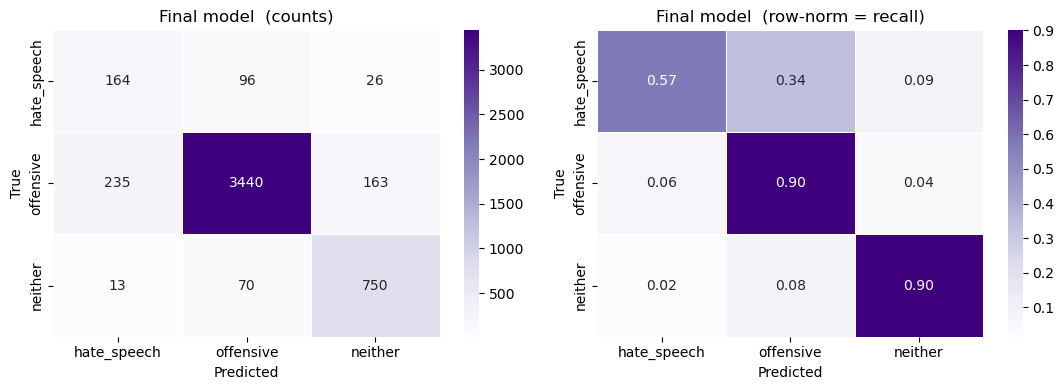

In [20]:
# ── final model: TF-IDF + confidence weight + calibrated + best θ ─
print("=== FINAL MODEL — detailed evaluation on test set ===")
print(classification_report(y_test, yp_th, target_names=TARGET_NAMES,
                             digits=4, zero_division=0))
plot_cm(y_test, yp_th, "Final model")

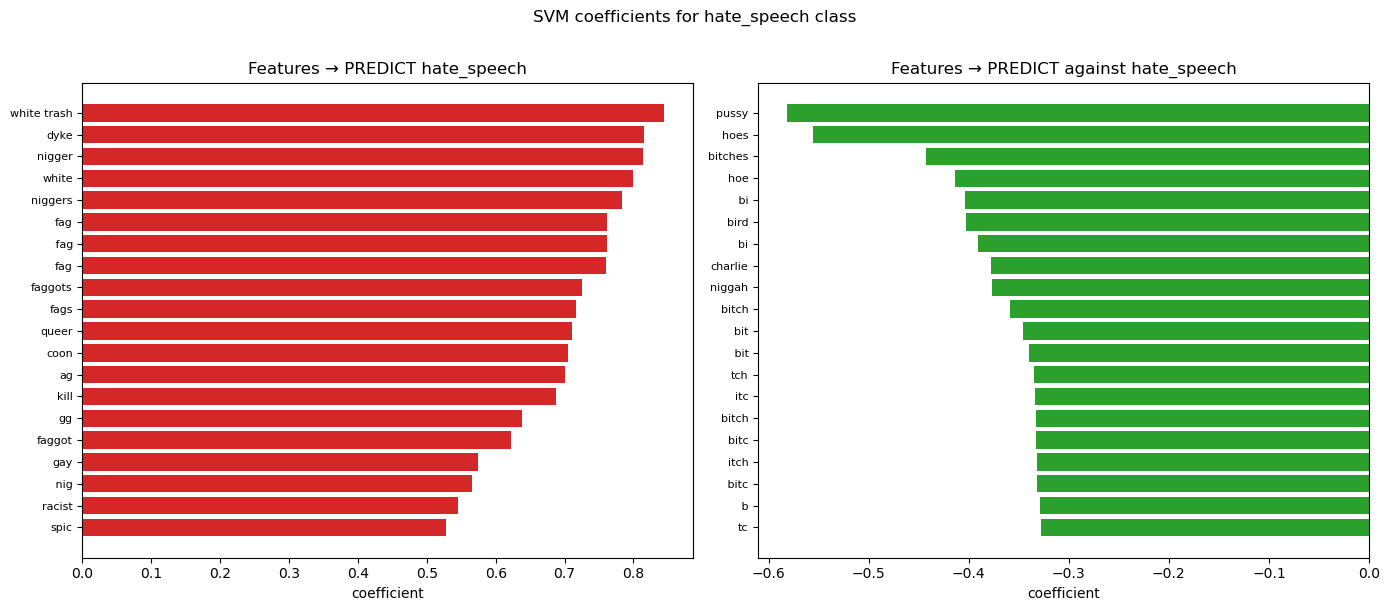

In [21]:
# ── feature importance: top n-grams pushing toward hate_speech ────
# refit a plain LinearSVC to access coefficients directly
interp_svc = LinearSVC(C=0.1, class_weight="balanced", random_state=SEED)
interp_svc.fit(X_tr_tfidf, y_train, sample_weight=sw_train)

vocab      = np.concatenate([word_vec.get_feature_names_out(),
                              char_vec.get_feature_names_out()])
coef_hate  = interp_svc.coef_[0]   # coefficients for class 0 (hate_speech)
n          = 20

top_for    = vocab[np.argsort(coef_hate)[-n:][::-1]]
top_against= vocab[np.argsort(coef_hate)[:n]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(range(n), np.sort(coef_hate)[-n:][::-1][::-1], color="#d62728")
axes[0].set_yticks(range(n)); axes[0].set_yticklabels(top_for[::-1], fontsize=8)
axes[0].set_title("Features → PREDICT hate_speech"); axes[0].set_xlabel("coefficient")

axes[1].barh(range(n), np.sort(coef_hate)[:n][::-1], color="#2ca02c")
axes[1].set_yticks(range(n)); axes[1].set_yticklabels(top_against[::-1], fontsize=8)
axes[1].set_title("Features → PREDICT against hate_speech"); axes[1].set_xlabel("coefficient")

plt.suptitle("SVM coefficients for hate_speech class", y=1.01)
plt.tight_layout(); plt.show()

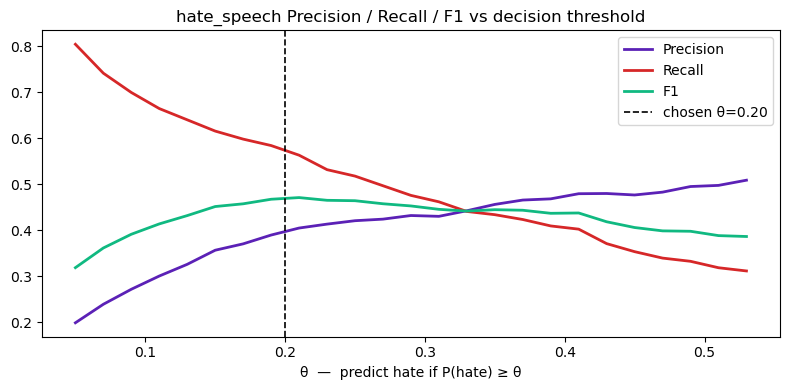

In [24]:
# ── precision-recall tradeoff across thresholds ───────────────────
thresholds = np.arange(0.05, 0.55, 0.02)
h_prec, h_rec, h_f1 = [], [], []
for th in thresholds:
    yp = np.where(test_probs[:,0] >= th, 0, np.argmax(test_probs[:,1:], axis=1)+1)
    h_prec.append(precision_score(y_test, yp, labels=[0], average="micro", zero_division=0))
    h_rec.append (recall_score   (y_test, yp, labels=[0], average="micro", zero_division=0))
    h_f1.append  (f1_score       (y_test, yp, labels=[0], average="micro", zero_division=0))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, h_prec, label="Precision", color="#5b21b6", lw=2)
ax.plot(thresholds, h_rec,  label="Recall",    color="#d62728", lw=2)
ax.plot(thresholds, h_f1,   label="F1",        color="#10b981", lw=2)
ax.axvline(best_th, color="black", ls="--", lw=1.2, label=f"chosen θ={best_th:.2f}")
ax.set_title("hate_speech Precision / Recall / F1 vs decision threshold")
ax.set_xlabel("θ  —  predict hate if P(hate) ≥ θ"); ax.legend()
plt.tight_layout(); plt.show()

**Feature importance interpretation:**

The top features pushing toward *hate_speech* are the specific slurs and targeted group-attack
phrases. The features pushing *against* hate_speech (toward offensive or neither) are generic
profanity that appears heavily in ordinary offensive conversation without a group target.

The model has learned the right associations. The residual errors — hate tweets classified as
offensive — occur when a tweet uses hateful vocabulary but the annotators judged it as ordinary
offensive language, or when the specific combination of tokens has not been seen in training.

**Threshold tradeoff:**

Lowering θ shifts recall up and precision down. The optimal θ (chosen on OOF predictions)
is where hate F1 peaks. Going below it raises recall further but false positives accumulate
faster, and hate F1 falls again. The chosen operating point balances both.

## 14. Conclusions

### The pipeline, in one line

`clean tweets → filter ambiguous offensive rows (conf < 0.67) → credibility-weight every row
(confidence × count/max) + class_weight=balanced → compare 5 embeddings → TF-IDF + LinearSVC,
calibrated, with an OOF-tuned hate threshold.`

### Best choice for each dimension

| Dimension | Winner | Why |
|:--|:--|:--|
| **Embedding** | TF-IDF (word 1–2 + char 2–5) | exact-match sparse weighting beats dense mean-pooling for short tweets where one rare token is the signal; char n-grams catch filter-evasion spellings |
| **Model** | LinearSVC | max-margin objective is ideal for high-dimensional sparse text; calibrated for threshold control |
| **Data cleaning** | Confidence filtering | removing ambiguous offensive rows (annotators split) sharpens the hate/offensive boundary far better than random undersampling |
| **Balancing** | Credibility weighting + class_weight | `confidence × count/max` trusts labels by both agreement and number of annotators; favours hate recall |

### Using the annotator signal — both ratio and count

The vote columns encode label reliability in two ways, and both are used:
- **Agreement ratio** (`confidence`) — how strongly the majority dominated.
- **Annotator count** (`count/max`) — how many people voted; a unanimous 9/9 is more trustworthy
  than a unanimous 3/3. Folding count in as a credibility multiplier shifts the operating point
  toward higher hate recall.

### Why hate F1 plateaus (~0.46)

Three structural limits no feature-engineering trick can cross:
1. **Vocabulary overlap** — hate and offensive use the same slurs; the discriminator is *intent
   and target*, invisible to a bag of words.
2. **Label noise** — hate labels carry only ~73% mean annotator agreement; some "errors" are
   genuine human disagreement.
3. **Data scarcity** — only ~915 hate tweets in training.

**Next step:** a fine-tuned transformer (DistilBERT / RoBERTa) reads the whole tweet with attention
and can encode *who is addressing whom* — the contextual signal that separates hate from offensive.
Published results on this dataset reach hate F1 ≈ 0.60–0.68, ~15 points above the TF-IDF ceiling.


In [43]:
import joblib, os

# ── Assemble les objets nécessaires ──────────────────────────────
model_artifacts = {
    "word_vec":  word_vec,       # TfidfVectorizer word 1-2
    "char_vec":  char_vec,       # TfidfVectorizer char 2-5
    "model":     cal_final,      # CalibratedClassifierCV(LinearSVC)
    "threshold": best_th,        # seuil optimal hate (ex: 0.18)
    "label_map": {0: "hate_speech", 1: "offensive", 2: "neither"}, 
}
# ── Sauvegarde ───────────────────────────────────────────────────
os.makedirs("../model", exist_ok=True)
joblib.dump(model_artifacts, "../model/hate_speech_model.pkl")
print("✅ Modèle exporté →  /model/hate_speech_model.pkl")

✅ Modèle exporté →  /model/hate_speech_model.pkl


In [36]:
import scipy.sparse as sp

tests = [
    "I love this community",
    "you are so stupid idiot", 
    "bitch",
    "fuck you",
    "go back to your country nobody wants you here",
    "kill all those freaks",
    "these people are disgusting animals",
    "shut up you worthless moron",
]

for text in tests:
    Xw = word_vec.transform([text])
    Xc = char_vec.transform([text])
    X  = sp.hstack([Xw, Xc])
    proba = cal_final.predict_proba(X)[0]
    
    if proba[0] >= best_th:
        idx = 0
    else:
        idx = int(np.argmax(proba[1:])) + 1
    
    label = TARGET_NAMES[idx]
    print(f"{label:15s} h={proba[0]:.2f} o={proba[1]:.2f} n={proba[2]:.2f}  → \"{text}\"")

offensive       h=0.02 o=0.51 n=0.47  → "I love this community"
hate_speech     h=0.32 o=0.34 n=0.34  → "you are so stupid idiot"
offensive       h=0.00 o=1.00 n=0.00  → "bitch"
offensive       h=0.16 o=0.84 n=0.00  → "fuck you"
offensive       h=0.07 o=0.65 n=0.28  → "go back to your country nobody wants you here"
hate_speech     h=0.48 o=0.38 n=0.13  → "kill all those freaks"
neither         h=0.10 o=0.33 n=0.58  → "these people are disgusting animals"
neither         h=0.07 o=0.45 n=0.48  → "shut up you worthless moron"


In [37]:
import joblib
import numpy as np
import re
from scipy.sparse import hstack
from nltk.corpus import stopwords

# ── 1. Charger les artifacts ──────────────────────────────────────
artifacts = joblib.load("../model/hate_speech_model.pkl")
word_vec  = artifacts["word_vec"]
char_vec  = artifacts["char_vec"]
model     = artifacts["model"]
best_th   = artifacts["threshold"]
label_map = artifacts["label_map"]

# ── 2. Même fonction de nettoyage que le notebook d'entraînement ──
STOP = set(stopwords.words("english"))

def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+",  " ", text)
    text = re.sub(r"@\w+",              " ", text)
    text = re.sub(r"&[a-z]+;|&#\d+;",  " ", text)
    text = re.sub(r"\brt\b",            " ", text)
    text = re.sub(r"[^a-z\s]",         " ", text)
    tokens = [w for w in text.split() if w not in STOP and len(w) > 1]
    return " ".join(tokens)

# ── 3. Prédire sur de nouveaux textes ────────────────────────────
def predict(texts):
    cleaned = [clean_tweet(t) for t in texts]
    Xw      = word_vec.transform(cleaned)
    Xc      = char_vec.transform(cleaned)
    X       = hstack([Xw, Xc]).tocsr()          # même hstack que l'entraînement
    probs   = model.predict_proba(X)
    preds   = np.where(probs[:,0] >= best_th, 0,
                       np.argmax(probs[:,1:], axis=1) + 1)
    return [label_map[p] for p in preds]

# ── Test rapide ───────────────────────────────────────────────────
texts = ["I hate those people", "this is a nice day", "you idiot pussy"]
for t, label in zip(texts, predict(texts)):
    print(f"{label:15s} | {t}")

hate            | I hate those people
normal          | this is a nice day
offensive       | you idiot pussy


In [45]:
import scipy.sparse as sp

test_texts = [
    "bitch",
    "fuck u",
    "I hate people like you, you should not exist",
    "Kill all those freaks, society is better without them",
    "You're so freaking stupid",
    "I love this community",
    "This is a great discussion, thanks for sharing!",
    "Go back to where you came from, nobody wants you here",
    "You're worthless and pathetic, get lost",
    "Great post! Very informative and well-researched",
]

print(f"θ = {best_th:.2f}\n")
for text in test_texts:
    cleaned = clean_tweet(text)
    Xw    = word_vec.transform([cleaned])
    Xc    = char_vec.transform([cleaned])
    X     = sp.hstack([Xw, Xc]).tocsr()
    proba = cal_final.predict_proba(X)[0]
    idx   = 0 if proba[0] >= best_th else int(np.argmax(proba[1:])) + 1
    label = LABEL_MAP[idx]
    print(f"[{label:<12}] {text}")

θ = 0.20

[offensive   ] bitch
[hate_speech ] fuck u
[hate_speech ] I hate people like you, you should not exist
[offensive   ] Kill all those freaks, society is better without them
[hate_speech ] You're so freaking stupid
[offensive   ] I love this community
[neither     ] This is a great discussion, thanks for sharing!
[offensive   ] Go back to where you came from, nobody wants you here
[offensive   ] You're worthless and pathetic, get lost
[neither     ] Great post! Very informative and well-researched
